In [5]:
%pip install pandas
%pip install seaborn
%pip install matplotlib
%pip install jinja2
%pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:

# 1. IMPORTS & VISUAL STYLING
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(67)

CUSTOM_PALETTE = ['#2B5B84', '#F4A261', '#E76F51', '#2A9D8F', '#E9C46A']
plt.rcParams.update({'figure.dpi': 150, 'figure.figsize': (10, 6), 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette(CUSTOM_PALETTE)


# 2. THE DATA LOADER
def load_all_tables_from_github() -> dict:
    
    base_url = "https://raw.githubusercontent.com/kori0494/datathon_work/refs/heads/main/data/"
    
    table_names = [
        'sales', 'customers', 'orders', 'order_items', 'products', 
        'promotions', 'shipments', 'returns', 'reviews', 'payments', 
        'geography', 'inventory', 'web_traffic'
    ]
    
    tables_dict = {}
    print("Downloading raw datasets from GitHub...\n")
    
    for name in table_names:
        file_url = f"{base_url}{name}.csv"
        
        try:
            # Download and read the CSV
            df = pd.read_csv(file_url)
            
            date_cols = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
            for col in date_cols:
                try:
                    df[col] = pd.to_datetime(df[col])
                except Exception:
                    pass 
            
            tables_dict[name] = df
            print(f"Loaded: {name.ljust(15)} | Shape: {df.shape[0]:,} rows")
            
        except Exception as e:
            print(f"Missing: {name.ljust(15)} | Skipped.")
            tables_dict[name] = None
            
    print("-" * 50)
    return tables_dict

# Run the function and save the dictionary to 'tables'
tables = load_all_tables_from_github()


Loaded: sales           | Shape: 3,833 rows
Loaded: customers       | Shape: 121,930 rows
Loaded: orders          | Shape: 646,945 rows
Loaded: order_items     | Shape: 714,669 rows
Loaded: products        | Shape: 2,412 rows
Loaded: promotions      | Shape: 50 rows
Loaded: shipments       | Shape: 566,067 rows
Loaded: returns         | Shape: 39,939 rows
Loaded: reviews         | Shape: 113,551 rows
Loaded: payments        | Shape: 646,945 rows
Loaded: geography       | Shape: 39,948 rows
Loaded: inventory       | Shape: 60,247 rows
Loaded: web_traffic     | Shape: 3,652 rows
--------------------------------------------------


In [7]:
from typing import Dict, Any


def profile_dataframe(name: str, tbl_df: pd.DataFrame) -> Dict[str, Any]:
    
    # 1. Datetime Handling
    date_cols = tbl_df.select_dtypes(include=['datetime', 'datetimetz']).columns
    
    if len(date_cols) > 0:
        min_date = tbl_df[date_cols].min().min().strftime('%Y-%m-%d')
        max_date = tbl_df[date_cols].max().max().strftime('%Y-%m-%d')
        date_range = f"{min_date} ➔ {max_date}"
    else:
        date_range = "N/A"
        
    # 2. Missing Value Formatting
    missing_pct = (tbl_df.isnull().sum() / len(tbl_df)) * 100
    missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False).round(1)
    
    if not missing_pct.empty:
        top_missing_str = ", ".join([f"{col} ({pct}%)" for col, pct in missing_pct.head(3).items()])
        if len(missing_pct) > 3:
            top_missing_str += " ..."
    else:
        top_missing_str = "Clean"
        
    # 3. Accurate Memory Calculation
    mem_mb = tbl_df.memory_usage(deep=True).sum() / (1024 * 1024)
    
    return {
        'Table Name': name.title().replace('_', ' '),
        'Rows': tbl_df.shape[0],
        'Columns': tbl_df.shape[1],
        'Memory (MB)': round(mem_mb, 2),
        'Date Range': date_range,
        'Cols w/ Missing': len(missing_pct),
        'Top Missing Features': top_missing_str,
        'Duplicates': int(tbl_df.duplicated().sum())
    }

print("Auditing all individual datasets for quality...\n")

audit_records = [profile_dataframe(name, tbl_df) for name, tbl_df in tables.items() if tbl_df is not None]

# Convert the results into a DataFrame
quality_df = pd.DataFrame(audit_records)

#Styling
styled_quality_report = (
    quality_df.style
    .format({'Rows': '{:,}'}) # Adds commas to large numbers
    .background_gradient(subset=['Cols w/ Missing', 'Duplicates'], cmap='Reds') # Highlights bad data
    .background_gradient(subset=['Memory (MB)'], cmap='Blues') # Highlights large files
    .set_caption("<b>Data Quality & Memory Audit Report</b>")
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '16px'), ('font-family', 'sans-serif')]
    }])
)

display(styled_quality_report)

Auditing all individual datasets for quality...



,Table Name,Rows,Columns,Memory (MB),Date Range,Cols w/ Missing,Top Missing Features,Duplicates
0,Sales,"3,833",3,0.090000,2012-07-04 ➔ 2022-12-31,0,Clean,0
1,Customers,"121,930",7,29.050000,2012-01-17 ➔ 2022-12-31,0,Clean,0
2,Orders,"646,945",8,162.780000,2012-07-04 ➔ 2022-12-31,0,Clean,0
3,Order Items,"714,669",7,78.000000,N/A,2,"promo_id_2 (100.0%), promo_id (61.3%)",0
4,Products,"2,412",8,0.710000,N/A,0,Clean,0
5,Promotions,50,10,0.020000,2013-01-31 ➔ 2022-12-31,1,applicable_category (80.0%),0
6,Shipments,"566,067",4,17.280000,2012-07-04 ➔ 2022-12-31,0,Clean,0
7,Returns,"39,939",7,6.080000,2012-07-11 ➔ 2022-12-31,0,Clean,0
8,Reviews,"113,551",7,17.760000,2012-07-10 ➔ 2022-12-31,0,Clean,0
9,Payments,"646,945",4,50.560000,N/A,0,Clean,0


Merging core tables to create the Master Dataset...
Master Dataset created successfully! Shape: 714,669 rows and 39 columns.

--------------------------------------------------
Analyzing missing values in the Master Dataset...



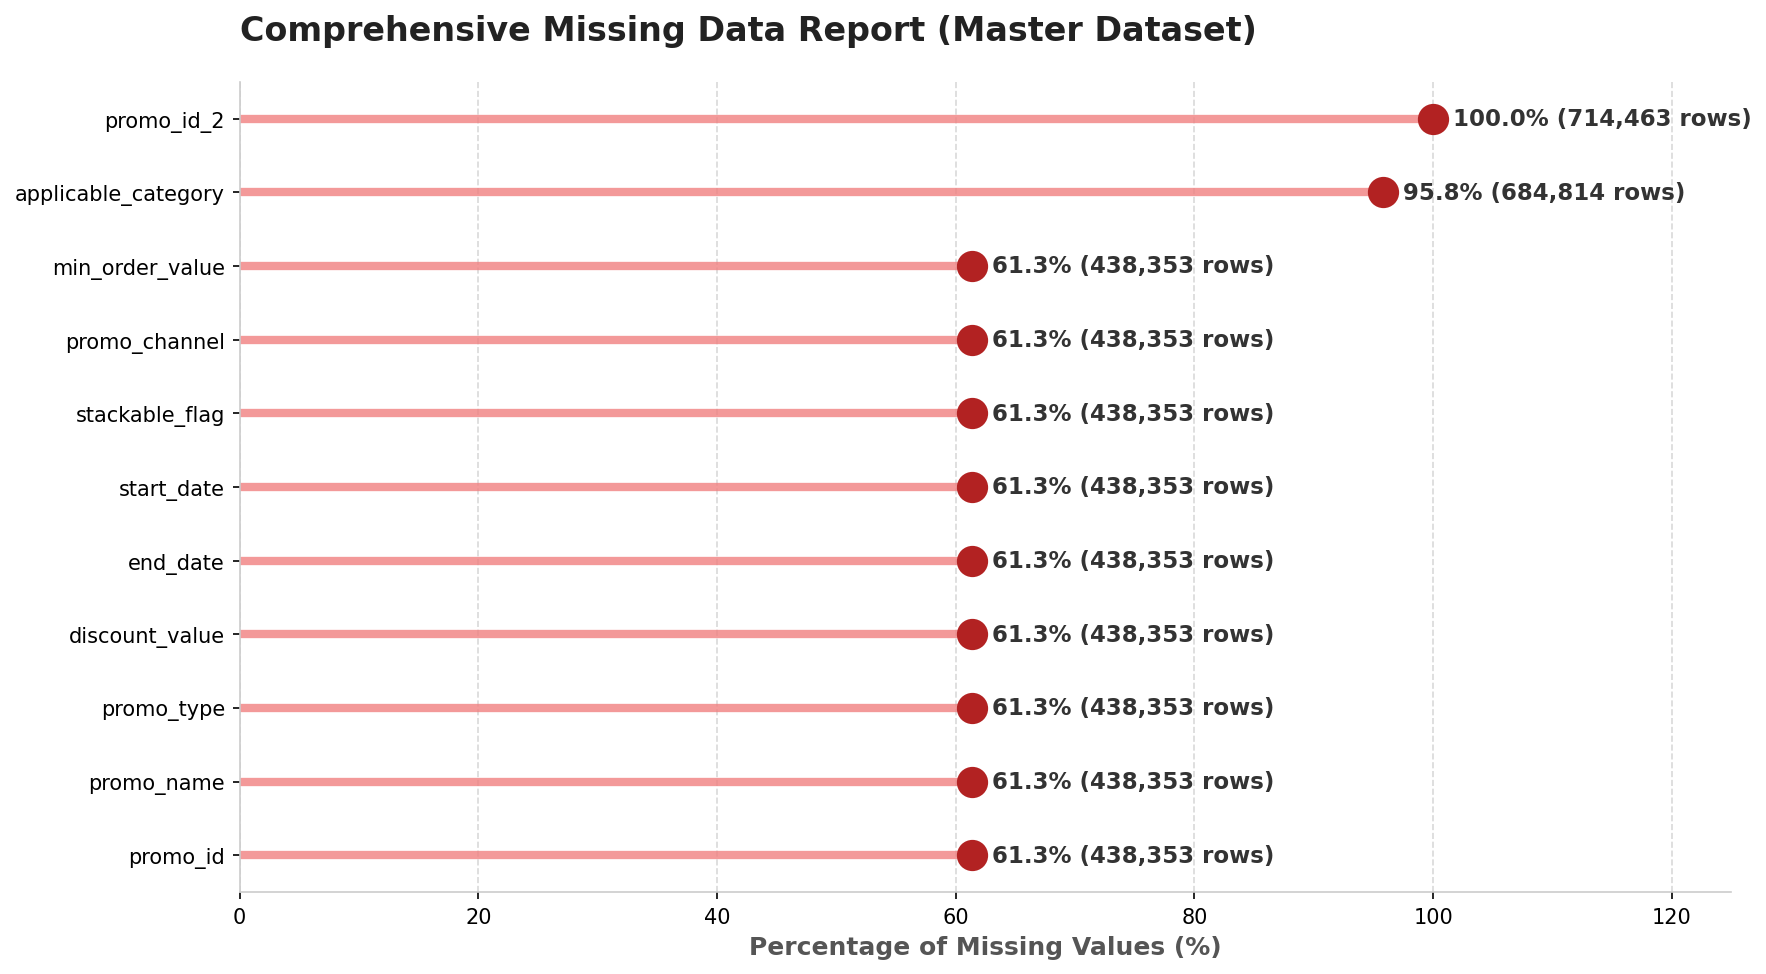

In [8]:

import pandas as pd
import matplotlib.pyplot as plt

print("Merging core tables to create the Master Dataset...")

# 1. Extract the core tables
orders = tables.get('orders')
order_items = tables.get('order_items')
products = tables.get('products')
customers = tables.get('customers')
payments = tables.get('payments')
promotions = tables.get('promotions') # ADDED PROMOTIONS!

# 2. Perform the Relational Merges

df = order_items.copy()

if orders is not None:
    df = df.merge(orders, on='order_id', how='left')
    
if products is not None:
    df = df.merge(products, on='product_id', how='left')
    
if customers is not None and 'customer_id' in df.columns:
    df = df.merge(customers, on='customer_id', how='left')

if payments is not None and 'order_id' in df.columns:
    payments_dedup = payments.drop_duplicates(subset=['order_id'])
    df = df.merge(payments_dedup, on='order_id', how='left')

# MERGING PROMOTIONS
if promotions is not None and 'promo_id' in df.columns:
    # This links the promo code used in the order to the marketing campaign details!
    df = df.merge(promotions, on='promo_id', how='left')

print(f"Master Dataset created successfully! Shape: {df.shape[0]:,} rows and {df.shape[1]} columns.\n")
print("-" * 50)


print("Analyzing missing values in the Master Dataset...\n")

# Calculate exact counts and percentages
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    'Feature': missing_counts.index,
    'Missing Count': missing_counts.values,
    'Missing Percentage (%)': missing_pct.values
})

# ONLY keep columns where Missing Count is greater than 0
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=True)

if missing_df.empty:
    print("Your master dataset is perfectly clean with zero missing values.")
else:
    # Give it a wider base and scale height perfectly
    chart_height = max(5, len(missing_df) * 0.6)
    plt.figure(figsize=(12, chart_height), facecolor='#ffffff')
    ax = plt.gca()
    
    # Draw the lines
    plt.hlines(y=missing_df['Feature'], xmin=0, xmax=missing_df['Missing Percentage (%)'], 
               color='lightcoral', alpha=0.8, linewidth=4)
    
    # Draw the dots
    plt.plot(missing_df['Missing Percentage (%)'], missing_df['Feature'], "o", 
             markersize=14, color='firebrick')

    # Add the text label (Percentage + Exact Rows)
    for idx, row in missing_df.reset_index(drop=True).iterrows():
        pct = row['Missing Percentage (%)']
        count = row['Missing Count']
        
        label_text = f" {pct:.1f}% ({int(count):,} rows)"
        
        plt.text(pct + 1, idx, label_text, 
                 va='center', fontsize=11, fontweight='bold', color='#333333')

    # Clean borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#cccccc')
    ax.spines['left'].set_color('#cccccc')

    plt.title('Comprehensive Missing Data Report (Master Dataset)', 
              fontsize=16, fontweight='900', color='#222222', pad=20, loc='left')
    plt.xlabel('Percentage of Missing Values (%)', fontsize=12, fontweight='bold', color='#555555')
    
    # Push the right margin way out (+ 25) so text never cuts off
    plt.xlim(0, missing_df['Missing Percentage (%)'].max() + 25) 
    
    plt.grid(axis='x', linestyle='--', color='black', alpha=0.15)
    plt.tight_layout()
    
    plt.savefig('missing_values_comprehensive.pdf', format='pdf', bbox_inches='tight')
    plt.show()

In [9]:
#Feature Tabulation
import pandas as pd
import numpy as np

print("Calculating core business metrics (Revenue, COGS, Profit)...")

# 1. Calculate Target Variables (Crucial for the Datathon!)
# Revenue = (Quantity * Price) - Discount
df['discount_amount'] = df['discount_amount'].fillna(0)
df['Revenue'] = (df['quantity'] * df['unit_price']) - df['discount_amount']

# COGS (Cost of Goods Sold) = Quantity * Unit Cost
if 'cogs' in df.columns:
    df['COGS'] = df['quantity'] * df['cogs']
    df['Profit'] = df['Revenue'] - df['COGS']

# PART A: NUMERICAL SUMMARY (THE BUSINESS METRICS)
print("\n--- 1. NUMERICAL DISTRIBUTION SUMMARY ---")

# Select only the most important numeric columns for business
numeric_cols = ['quantity', 'unit_price', 'discount_amount', 'Revenue', 'COGS', 'Profit']
existing_num_cols = [col for col in numeric_cols if col in df.columns]

# Calculate the statistics
num_summary = df[existing_num_cols].describe().T

# Drop the 'count' column (we know how big the dataset is) and round things
num_summary = num_summary.drop('count', axis=1).round(2)

# Style it beautifully for the judges
styled_num = (
    num_summary.style
    .format("{:,.2f}") # Add commas for thousands (e.g., 10,000.00)
    .background_gradient(subset=['mean', '50%', 'max'], cmap='Greens') # Heatmap for highs
    .background_gradient(subset=['min'], cmap='Reds') # Heatmap for lows (e.g., negative profit)
    .set_caption("<b>Key Financial Distributions</b>")
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '16px')]}])
)
display(styled_num)

# PART B: CATEGORICAL SUMMARY (THE BUSINESS SEGMENTS)

print("\n--- 2. CATEGORICAL SEGMENT SUMMARY ---")

# Select interesting categorical features
cat_cols = ['order_status', 'payment_method', 'device_type', 'category', 'segment', 'promo_type']
existing_cat_cols = [col for col in cat_cols if col in df.columns]

# Build a custom summary dataframe
cat_summary = pd.DataFrame(index=existing_cat_cols)
cat_summary['Unique Categories'] = [df[col].nunique() for col in existing_cat_cols]
cat_summary['Top Category (Mode)'] = [df[col].mode()[0] for col in existing_cat_cols]
cat_summary['Top % Share'] = [round((df[col].value_counts(normalize=True).iloc[0] * 100), 1) for col in existing_cat_cols]

# Format the percentage column to look like "45.2%"
cat_summary['Top % Share'] = cat_summary['Top % Share'].astype(str) + "%"

# Style the categorical table
styled_cat = (
    cat_summary.style
    .background_gradient(subset=['Unique Categories'], cmap='Purples')
    .set_caption("<b>Categorical Feature Dominance</b>")
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '16px')]}])
)
display(styled_cat)

Calculating core business metrics (Revenue, COGS, Profit)...

--- 1. NUMERICAL DISTRIBUTION SUMMARY ---


,mean,std,min,25%,50%,75%,max
quantity,4.50,2.29,1.00,2.00,4.00,6.00,8.00
unit_price,"5,114.69","3,774.82",392.57,"1,906.89","4,257.77","7,273.76","43,056.00"
discount_amount,"1,048.89","2,280.53",0.00,0.00,0.00,967.63,"35,235.47"
Revenue,"21,941.44","21,712.28",389.74,"6,041.64","14,518.07","30,635.50","331,570.40"
COGS,"19,818.20","19,987.24",346.31,"5,277.21","13,013.78","27,265.63","311,220.00"
Profit,"2,123.25","7,575.19","-75,957.12",-173.94,"1,116.91","4,041.10","80,311.61"



--- 2. CATEGORICAL SEGMENT SUMMARY ---


,Unique Categories,Top Category (Mode),Top % Share
order_status,6,delivered,79.9%
device_type,3,mobile,45.0%
category,4,Streetwear,55.1%
segment,8,Activewear,32.2%
promo_type,2,percentage,92.4%


Analyzing Categorical Cardinality for ML Encoding Strategy...



NameError: name 'Patch' is not defined

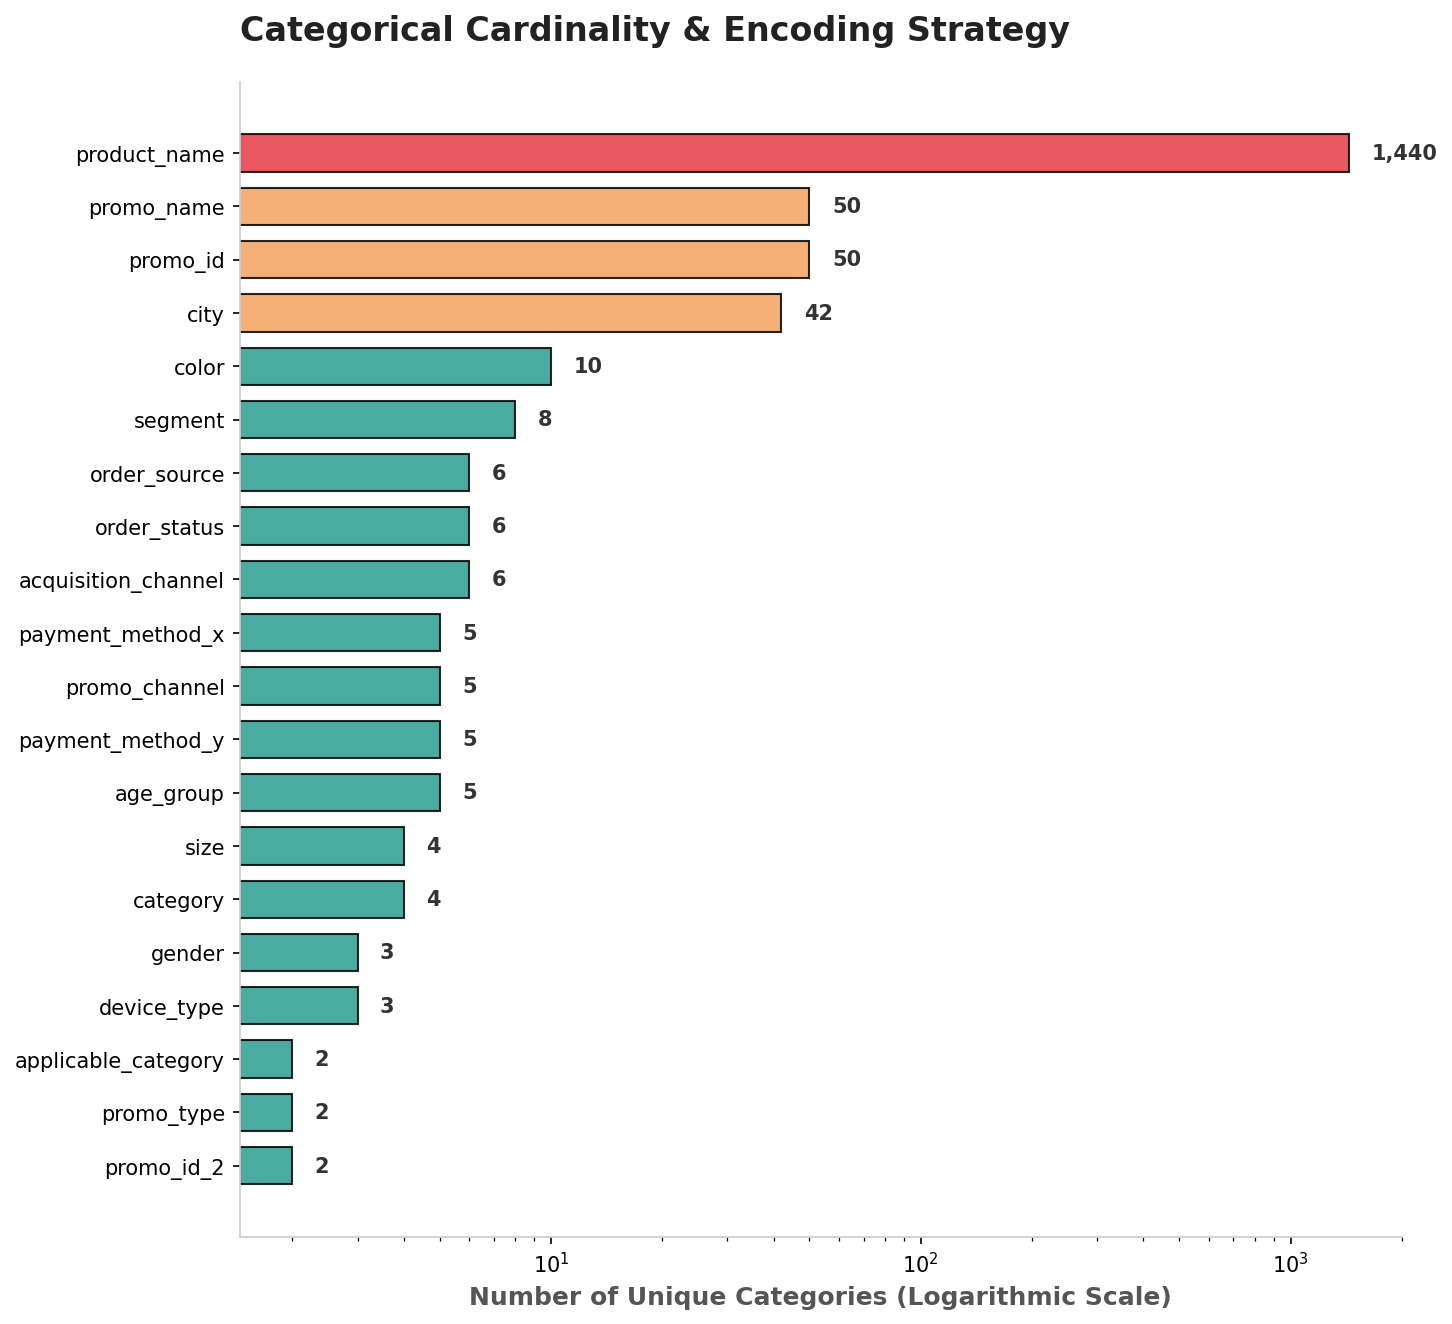

In [10]:

print("Analyzing Categorical Cardinality for ML Encoding Strategy...\n")

# 1. Identify Categorical Columns in the Master Dataset
cat_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Calculate cardinality (number of unique values) and sort from highest to lowest
cardinality = df[cat_features].nunique().sort_values(ascending=True)

# Create a clean DataFrame
cardinality_df = pd.DataFrame({
    'Feature': cardinality.index,
    'Unique Values': cardinality.values
})

if cardinality_df.empty:
    print("No categorical features found.")
else:
    # 2. Define ML Encoding Strategy based on Cardinality Thresholds
    def assign_strategy(val):
        if val <= 15:
            return "One-Hot Encoding (Low Risk)"
        elif val <= 100:
            return "Frequency Encoding (Medium Risk)"
        else:
            return "Target Encoding (High Risk)"

    cardinality_df['Recommended Strategy'] = cardinality_df['Unique Values'].apply(assign_strategy)

    plt.figure(figsize=(10, max(5, len(cardinality_df) * 0.5)), facecolor='#ffffff')
    ax = plt.gca()

    # Define colors based on the ML Strategy
    # Red for High (>100), Orange for Medium (>15), Green for Low/Safe (<=15)
    colors = ['#e63946' if val > 100 else ('#f4a261' if val > 15 else '#2a9d8f') 
              for val in cardinality_df['Unique Values']]

    # Draw the bars
    bars = plt.barh(cardinality_df['Feature'], cardinality_df['Unique Values'], 
                    color=colors, edgecolor='black', alpha=0.85, height=0.7)

    # Add the exact numbers next to the bars
    for bar in bars:
        width = bar.get_width()
        # We multiply by 1.15 to push the text slightly past the end of the bar on a log scale
        plt.text(width * 1.15, bar.get_y() + bar.get_height()/2, f"{int(width):,}", 
                 va='center', fontsize=10, fontweight='bold', color='#333333')

    ax.set_xscale('log')

    # Clean borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#cccccc')
    ax.spines['left'].set_color('#cccccc')

    # Formatting
    plt.title('Categorical Cardinality & Encoding Strategy', 
              fontsize=16, fontweight='900', color='#222222', pad=20, loc='left')
    plt.xlabel('Number of Unique Categories (Logarithmic Scale)', fontsize=12, fontweight='bold', color='#555555')
    
    # Custom Legend for the Judges
    legend_elements = [
        Patch(facecolor='#2a9d8f', edgecolor='black', label='< 15 (Safe for One-Hot)'),
        Patch(facecolor='#f4a261', edgecolor='black', label='16 - 100 (Frequency Encode)'),
        Patch(facecolor='#e63946', edgecolor='black', label='> 100 (Target/Embedding Encode)')
    ]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True, facecolor='white')

    # Lock the x-axis minimum to 1 to prevent log(0) visual glitches
    plt.xlim(1, cardinality_df['Unique Values'].max() * 10)
    plt.grid(axis='x', linestyle='--', color='black', alpha=0.1)

    plt.tight_layout()
    plt.savefig('categorical_cardinality_log.pdf', format='pdf', bbox_inches='tight')
    plt.show()

    # Sort descending so the highest risk features are at the top of the table
    display_df = cardinality_df.sort_values(by='Unique Values', ascending=False)
    
    styled_card = (
        display_df.style
        .format({'Unique Values': '{:,}'})
        .background_gradient(subset=['Unique Values'], cmap='Reds')
        .set_caption("<b>Categorical Feature Encoding Roadmap</b>")
        .set_table_styles([{'selector': 'caption', 'props': [('font-size', '16px')]}])
    )
    display(styled_card)